# SIHEDAF 2.0 — Visualisasi & Evaluasi Model Deteksi AFIB

Notebook ini mengimpor hasil dari `modul.py` dan menyajikan:
1. Distribusi RR-Interval: Normal vs AFIB
2. Confusion Matrix per model
3. ROC Curve
4. Feature Importance
5. Statistik deskriptif

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay

from modul import (
    multi_record_pipeline,
    train_evaluate_models,
    preprocess_single_record,
    predict_rhythm,
)

# Style setting
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

## Tahap 1-3: Preprocessing, Segmentasi, Ekstraksi Fitur HRV

In [2]:
# Jalankan pipeline multi-record (Tahap 1-3)
df_all, patient_ids = multi_record_pipeline(files_dir='files', window_size=100)

print(f"\nShape dataset: {df_all.shape}")
print(f"Kolom: {list(df_all.columns)}")
df_all.head()

Record valid ditemukan: 23
  Memproses 04015... 

431 segmen (N=429, AFIB=2)
  Memproses 04043... 

476 segmen (N=397, AFIB=79)
  Memproses 04048... 

388 segmen (N=384, AFIB=4)
  Memproses 04126... 

415 segmen (N=388, AFIB=27)
  Memproses 04746... 

...

410 segmen (N=300, AFIB=110)
  Memproses 08405... 

586 segmen (N=136, AFIB=450)
  Memproses 08434... 

394 segmen (N=373, AFIB=21)
  Memproses 08455... 

592 segmen (N=151, AFIB=441)

═══ TOTAL ═══
Total segmen : 10713
Normal (0)   : 5855
AFIB (1)     : 4858
Pasien unik  : 23

Shape dataset: (10713, 11)
Kolom: ['Mean_RR', 'SDNN', 'RMSSD', 'pNN50', 'CV', 'SD1', 'SD2', 'SD1_SD2_ratio', 'SampEn', 'Label', 'Patient']


,Mean_RR,SDNN,RMSSD,pNN50,CV,SD1,SD2,SD1_SD2_ratio,SampEn,Label,Patient
0,0.66058,0.165722,0.090452,38.383838,0.250874,0.064285,0.226157,0.284248,1.011601,0,04015
1,0.63484,0.141465,0.105268,50.505051,0.222836,0.074776,0.184828,0.404569,0.965716,0,04015
2,0.52740,0.082638,0.067076,38.383838,0.156690,0.047620,0.101603,0.468690,0.857450,0,04015
3,0.61688,0.172634,0.059727,38.383838,0.279850,0.042444,0.238215,0.178176,0.698262,0,04015
4,0.64456,0.131326,0.099822,51.515152,0.203744,0.070896,0.169913,0.417249,1.256241,0,04015


## Distribusi RR-Interval: Normal vs AFIB (Record 04015)

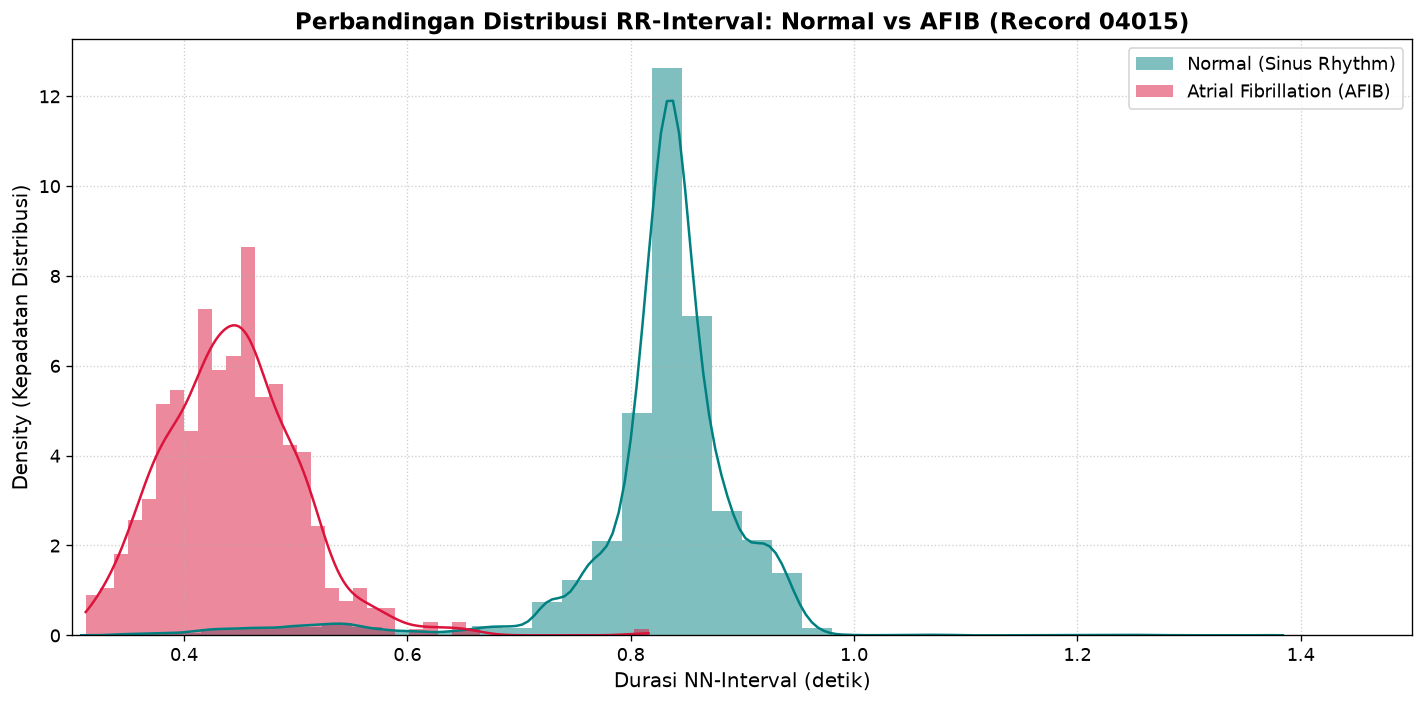


=== STATISTIK RR-INTERVAL (Record 04015) ===
          count      mean       std    min    25%    50%   75%    max
Rhythm                                                               
AFIB      524.0  0.442855  0.060072  0.312  0.400  0.444  0.48  0.816
N       43476.0  0.824953  0.082434  0.308  0.812  0.836  0.86  1.384


In [3]:
# Visualisasi distribusi RR-Interval untuk satu record (04015)
nn_intervals, labels, is_valid = preprocess_single_record('files/04015')

df_rr = pd.DataFrame({'NN_Interval': nn_intervals, 'Rhythm': labels})
df_rr_clean = df_rr[(df_rr['NN_Interval'] >= 0.3) & (df_rr['NN_Interval'] <= 1.5)]

normal_rr = df_rr_clean[df_rr_clean['Rhythm'] == 'N']['NN_Interval']
afib_rr = df_rr_clean[df_rr_clean['Rhythm'] == 'AFIB']['NN_Interval']

plt.figure(figsize=(12, 6))
sns.histplot(normal_rr, kde=True, color='teal', label='Normal (Sinus Rhythm)',
             stat='density', alpha=0.5, bins=40, edgecolor='none')
sns.histplot(afib_rr, kde=True, color='crimson', label='Atrial Fibrillation (AFIB)',
             stat='density', alpha=0.5, bins=40, edgecolor='none')

plt.title('Perbandingan Distribusi RR-Interval: Normal vs AFIB (Record 04015)',
          fontsize=14, weight='bold')
plt.xlabel('Durasi NN-Interval (detik)', fontsize=12)
plt.ylabel('Density (Kepadatan Distribusi)', fontsize=12)
plt.xlim(0.3, 1.5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\n=== STATISTIK RR-INTERVAL (Record 04015) ===")
print(df_rr_clean.groupby('Rhythm')['NN_Interval'].describe())

## Distribusi Fitur HRV per Kelas

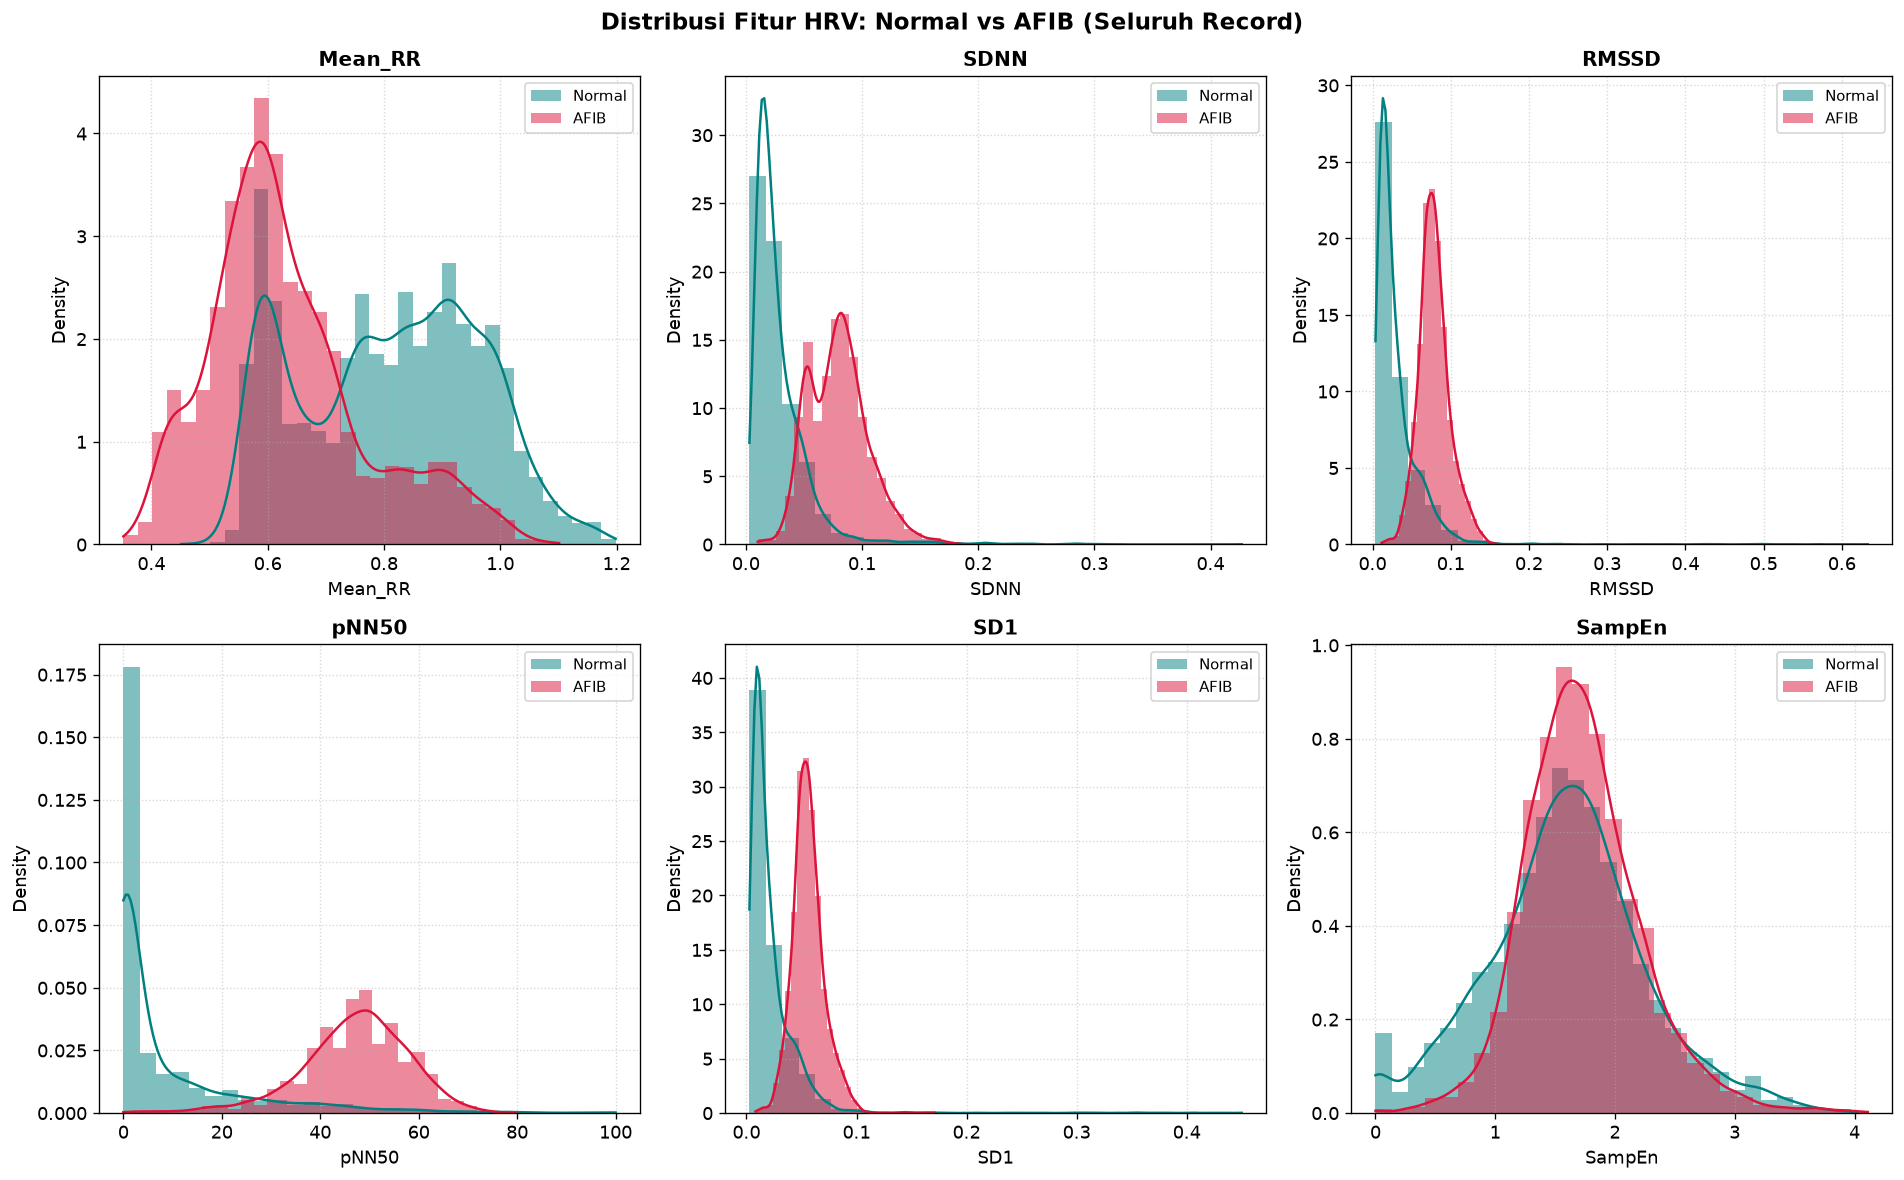

In [4]:
# Distribusi beberapa fitur HRV kunci: Normal vs AFIB
key_features = ['Mean_RR', 'SDNN', 'RMSSD', 'pNN50', 'SD1', 'SampEn']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    ax = axes[i]
    normal_vals = df_all[df_all['Label'] == 0][feat]
    afib_vals = df_all[df_all['Label'] == 1][feat]

    sns.histplot(normal_vals, kde=True, color='teal', label='Normal',
                 stat='density', alpha=0.5, bins=30, edgecolor='none', ax=ax)
    sns.histplot(afib_vals, kde=True, color='crimson', label='AFIB',
                 stat='density', alpha=0.5, bins=30, edgecolor='none', ax=ax)

    ax.set_title(feat, fontsize=12, weight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.5)

fig.suptitle('Distribusi Fitur HRV: Normal vs AFIB (Seluruh Record)',
             fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

## Tahap 4: Pemodelan ML (Patient-Independent)

In [5]:
# Latih dan evaluasi model
results, best_model, best_scaler, feature_names = train_evaluate_models(df_all)


════ TAHAP 4: PEMODELAN ML (PATIENT-INDEPENDENT) ════

── Random Forest ──


  Akurasi      : 0.9417
  Sensitivitas : 0.9082
  Spesifisitas : 0.9694
  F1-Score     : 0.9339
  ROC-AUC      : 0.9904
  Confusion Mx : [[5676, 179], [446, 4412]]



── SVM ──


  Akurasi      : 0.9535
  Sensitivitas : 0.9387
  Spesifisitas : 0.9658
  F1-Score     : 0.9482
  ROC-AUC      : 0.9903
  Confusion Mx : [[5655, 200], [298, 4560]]



── MLP ──


  Akurasi      : 0.9453
  Sensitivitas : 0.9228
  Spesifisitas : 0.9640
  F1-Score     : 0.9387
  ROC-AUC      : 0.9898
  Confusion Mx : [[5644, 211], [375, 4483]]

✓ Model terbaik (SVM, F1=0.9482) disimpan ke models/best_model.joblib
✓ Scaler disimpan ke models/scaler.joblib


### Tabel Perbandingan Metrik

In [6]:
# Tabel ringkasan metrik
metrics_summary = []
for name, res in results.items():
    metrics_summary.append({
        'Model': name,
        'Akurasi': f"{res['accuracy']:.4f}",
        'Sensitivitas': f"{res['sensitivity']:.4f}",
        'Spesifisitas': f"{res['specificity']:.4f}",
        'F1-Score': f"{res['f1_score']:.4f}",
        'ROC-AUC': f"{res['roc_auc']:.4f}",
    })

df_metrics = pd.DataFrame(metrics_summary)
print(df_metrics.to_string(index=False))
df_metrics

        Model Akurasi Sensitivitas Spesifisitas F1-Score ROC-AUC
Random Forest  0.9417       0.9082       0.9694   0.9339  0.9904
          SVM  0.9535       0.9387       0.9658   0.9482  0.9903
          MLP  0.9453       0.9228       0.9640   0.9387  0.9898


,Model,Akurasi,Sensitivitas,Spesifisitas,F1-Score,ROC-AUC
0,Random Forest,0.9417,0.9082,0.9694,0.9339,0.9904
1,SVM,0.9535,0.9387,0.9658,0.9482,0.9903
2,MLP,0.9453,0.9228,0.9640,0.9387,0.9898


### Confusion Matrix

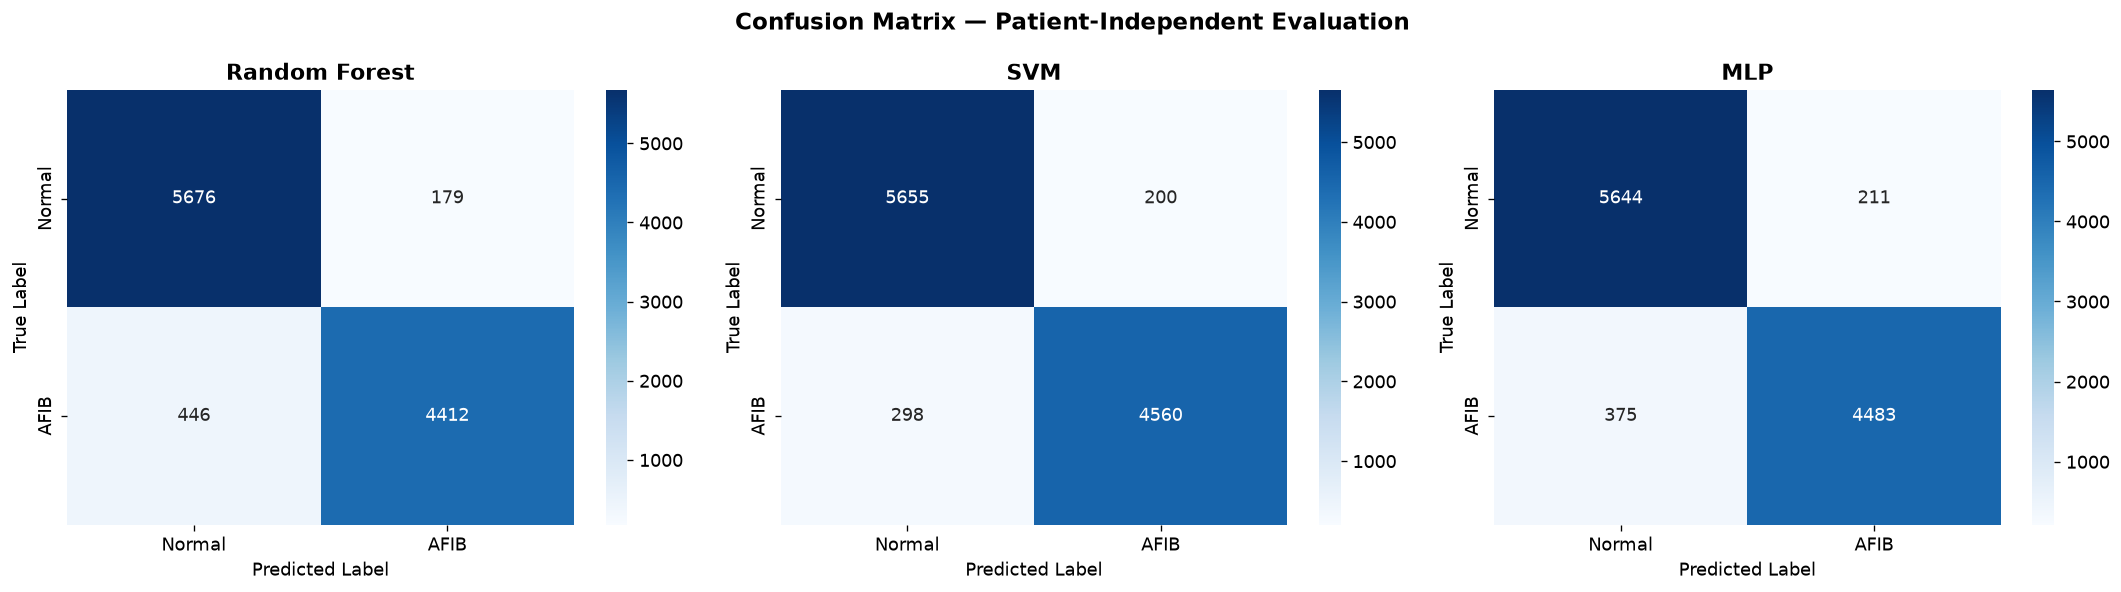

In [7]:
# Confusion Matrix untuk setiap model
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
if len(results) == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    cm = res['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'AFIB'],
                yticklabels=['Normal', 'AFIB'])
    ax.set_title(f'{name}', fontsize=13, weight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

fig.suptitle('Confusion Matrix — Patient-Independent Evaluation',
             fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

### ROC Curve

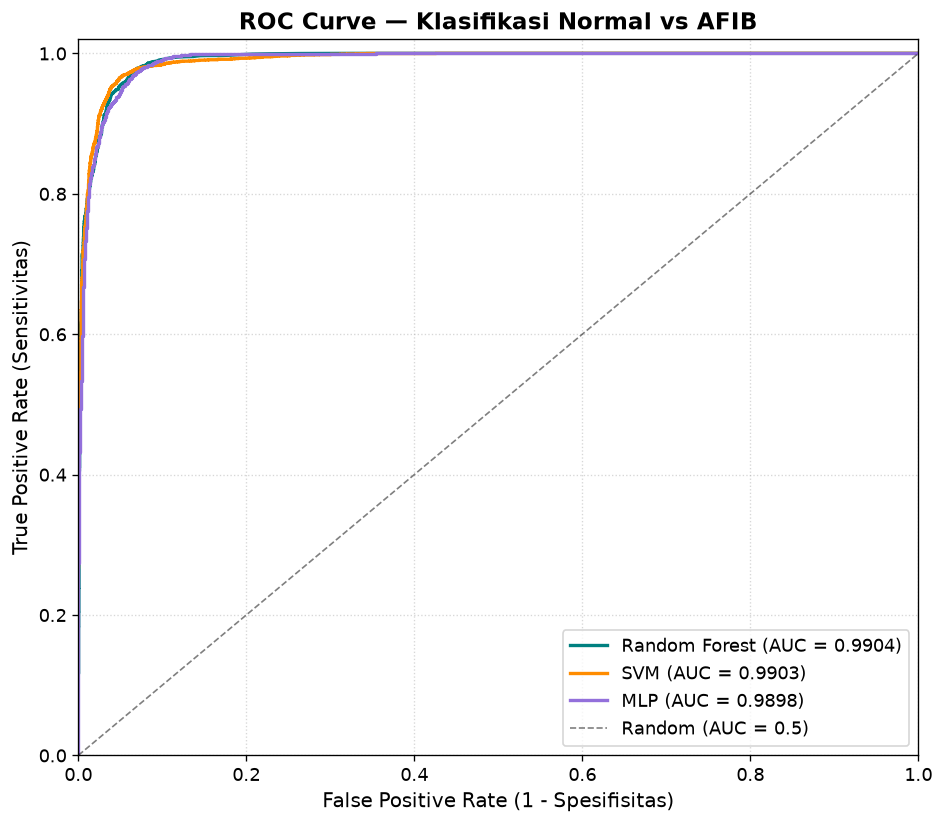

In [8]:
# ROC Curve untuk semua model
plt.figure(figsize=(8, 7))

colors = {'Random Forest': 'teal', 'SVM': 'darkorange', 'MLP': 'mediumpurple'}

for name, res in results.items():
    fpr, tpr, _ = roc_curve(res['y_true'], res['y_prob'])
    roc_auc_val = auc(fpr, tpr)
    color = colors.get(name, 'gray')
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{name} (AUC = {roc_auc_val:.4f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.5)')
plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.xlabel('False Positive Rate (1 - Spesifisitas)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivitas)', fontsize=12)
plt.title('ROC Curve — Klasifikasi Normal vs AFIB', fontsize=14, weight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

### Feature Importance (Random Forest)

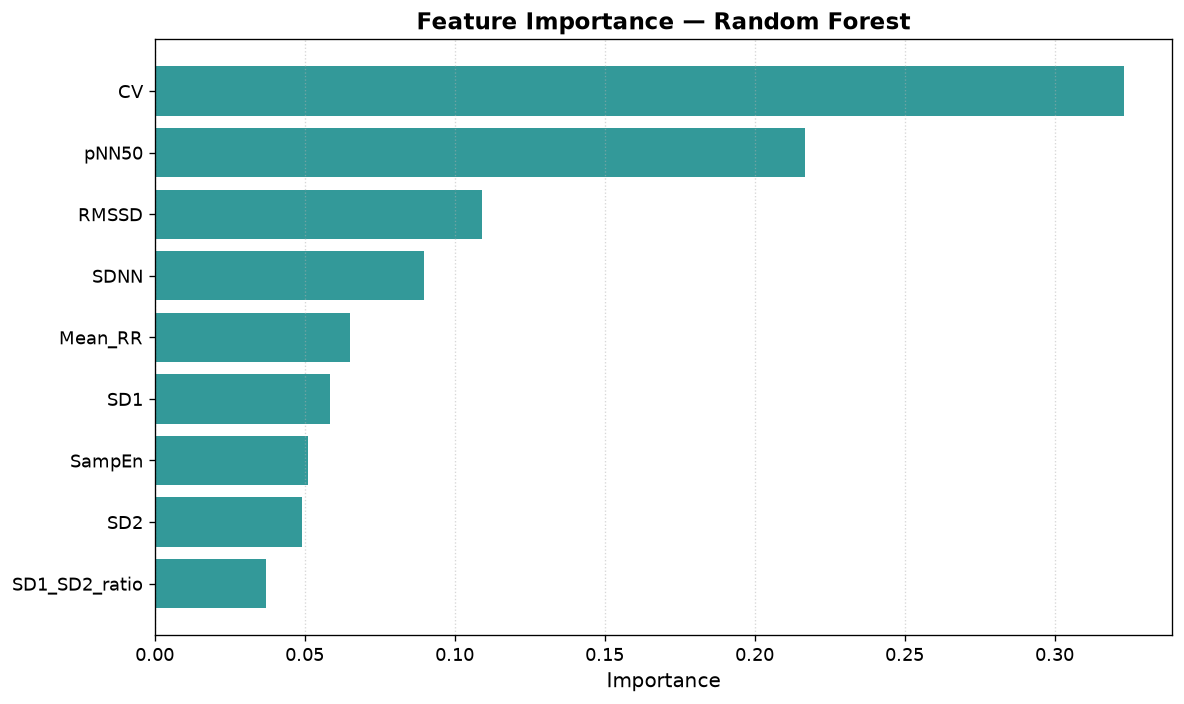

In [9]:
# Feature Importance dari model Random Forest (jika ada)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
else:
    # Re-train RF untuk mendapatkan feature importance
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.preprocessing import StandardScaler
    feature_cols = [c for c in df_all.columns if c not in ('Label', 'Patient')]
    X_all = df_all[feature_cols].values
    y_all = df_all['Label'].values
    sc = StandardScaler()
    X_sc = sc.fit_transform(X_all)
    rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
    rf.fit(X_sc, y_all)
    importances = rf.feature_importances_
    feature_names = feature_cols

# Sortir dan plot
sorted_idx = np.argsort(importances)[::-1]
sorted_names = [feature_names[i] for i in sorted_idx]
sorted_imp = importances[sorted_idx]

plt.figure(figsize=(10, 6))
bars = plt.barh(range(len(sorted_names)), sorted_imp[::-1], color='teal', alpha=0.8)
plt.yticks(range(len(sorted_names)), sorted_names[::-1], fontsize=11)
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importance — Random Forest', fontsize=14, weight='bold')
plt.grid(True, axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## Tahap 5: Test Fungsi Inferensi Backend

In [10]:
# Test fungsi inferensi dengan data sampel
nn_sample, labels_sample, _ = preprocess_single_record('files/04015')

# Test dengan interval Normal
normal_nn = nn_sample[labels_sample == 'N'][:100]
result_normal = predict_rhythm(normal_nn)
print("=== Test Inferensi (input Normal) ===")
print(f"  Prediksi    : {result_normal['prediction']}")
print(f"  Probabilitas: {result_normal['probability']:.4f}")

# Test dengan interval AFIB
afib_nn = nn_sample[labels_sample == 'AFIB'][:100]
if len(afib_nn) >= 10:
    result_afib = predict_rhythm(afib_nn)
    print("\n=== Test Inferensi (input AFIB) ===")
    print(f"  Prediksi    : {result_afib['prediction']}")
    print(f"  Probabilitas: {result_afib['probability']:.4f}")
else:
    print("\n(Tidak cukup data AFIB di record 04015 untuk test)")

=== Test Inferensi (input Normal) ===
  Prediksi    : AFIB
  Probabilitas: 0.8136

=== Test Inferensi (input AFIB) ===
  Prediksi    : AFIB
  Probabilitas: 1.0000
